In [10]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df1 = pd.read_csv('../ncbi_562_data.csv')
df2 = pd.read_csv('../ncbi_590_data.csv')


C:\Users\bryan_crnqtx7\AppData\Local\Temp\ipykernel_1892\1438472862.py:6: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('../ncbi_590_data.csv')


In [11]:
df1 = df1[df1['is_usa_based'] == 1]
df1['collection_year'] = pd.to_numeric(df1['collection_year'], errors='coerce')
df1 = df1[df1['collection_year'] >= 2009]
df1 = df1[df1['month'].notna()]
df1['collection_year'] = df1['collection_year'].astype(str)
df1['collection_year'] = df1['collection_year'].str[:4]
df1['month'] = df1['month'].astype(int)
df1['month'] = df1['month'].apply(lambda x: f"{x:02d}")
df1['year_and_month'] = df1['collection_year'] + '-' + df1['month']

df2 = df2[df2['is_usa_based'] == 1]
df2['collection_year'] = pd.to_numeric(df2['collection_year'], errors='coerce')
df2 = df2[df2['collection_year'] >= 2009]
df2 = df2[df2['month'].notna()]
df2['collection_year'] = df2['collection_year'].astype(str)
df2['collection_year'] = df2['collection_year'].str[:4]
df2['month'] = df2['month'].astype(int)
df2['month'] = df2['month'].apply(lambda x: f"{x:02d}")
df2['year_and_month'] = df2['collection_year'] + '-' + df2['month']

In [12]:
year_month_counts1 = df1['year_and_month'].value_counts().sort_index()
#add counts of 0 for each month of each year where there is no count
for i in range(1, 13):
    for j in range(1974, 2024):
        year_month = f"{j}-{i:02d}"
        if year_month not in year_month_counts1.index:
            year_month_counts1[year_month] = 0
year_month_counts1 = year_month_counts1.sort_index()
year_month_counts2 = df2['year_and_month'].value_counts().sort_index()
for i in range(1, 13):
    for j in range(1974, 2024):
        year_month = f"{j}-{i:02d}"
        if year_month not in year_month_counts2.index:
            year_month_counts2[year_month] = 0
year_month_counts2 = year_month_counts2.sort_index()




In [13]:
#Make a sum of counts where the last three characters are -01 as January, -02 for February, etc.
monthly_counts1 = year_month_counts1.groupby(year_month_counts1.index.str[-2:]).sum()
monthly_counts2 = year_month_counts2.groupby(year_month_counts2.index.str[-2:]).sum()


In [14]:
#Replace 01 with Jan, 02 with Feb, etc
monthly_counts1.index = monthly_counts1.index.str.replace('01', 'Jan')
monthly_counts1.index = monthly_counts1.index.str.replace('02', 'Feb')
monthly_counts1.index = monthly_counts1.index.str.replace('03', 'Mar')
monthly_counts1.index = monthly_counts1.index.str.replace('04', 'Apr')
monthly_counts1.index = monthly_counts1.index.str.replace('05', 'May')
monthly_counts1.index = monthly_counts1.index.str.replace('06', 'Jun')
monthly_counts1.index = monthly_counts1.index.str.replace('07', 'Jul')
monthly_counts1.index = monthly_counts1.index.str.replace('08', 'Aug')
monthly_counts1.index = monthly_counts1.index.str.replace('09', 'Sep')
monthly_counts1.index = monthly_counts1.index.str.replace('10', 'Oct')
monthly_counts1.index = monthly_counts1.index.str.replace('11', 'Nov')
monthly_counts1.index = monthly_counts1.index.str.replace('12', 'Dec')

monthly_counts2.index = monthly_counts2.index.str.replace('01', 'Jan')
monthly_counts2.index = monthly_counts2.index.str.replace('02', 'Feb')
monthly_counts2.index = monthly_counts2.index.str.replace('03', 'Mar')
monthly_counts2.index = monthly_counts2.index.str.replace('04', 'Apr')
monthly_counts2.index = monthly_counts2.index.str.replace('05', 'May')
monthly_counts2.index = monthly_counts2.index.str.replace('06', 'Jun')
monthly_counts2.index = monthly_counts2.index.str.replace('07', 'Jul')
monthly_counts2.index = monthly_counts2.index.str.replace('08', 'Aug')
monthly_counts2.index = monthly_counts2.index.str.replace('09', 'Sep')
monthly_counts2.index = monthly_counts2.index.str.replace('10', 'Oct')
monthly_counts2.index = monthly_counts2.index.str.replace('11', 'Nov')
monthly_counts2.index = monthly_counts2.index.str.replace('12', 'Dec')


In [15]:
monthly_counts1

year_and_month
Jan    4649
Feb    3752
Mar    4327
Apr    4528
May    5880
Jun    7092
Jul    8307
Aug    7953
Sep    6388
Oct    5753
Nov    5125
Dec    3933
Name: count, dtype: int64

In [16]:

monthly_avg_temps = [60*50, 60*60, 60*70, 60*80, 60*90, 60*100, 60*90, 60*85, 60*75, 60*65, 60*55, 60*45]
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
months_and_temps = dict(zip(months, monthly_avg_temps))
months_and_temps = pd.Series(months_and_temps)
months_and_temps

Jan    3000
Feb    3600
Mar    4200
Apr    4800
May    5400
Jun    6000
Jul    5400
Aug    5100
Sep    4500
Oct    3900
Nov    3300
Dec    2700
dtype: int64

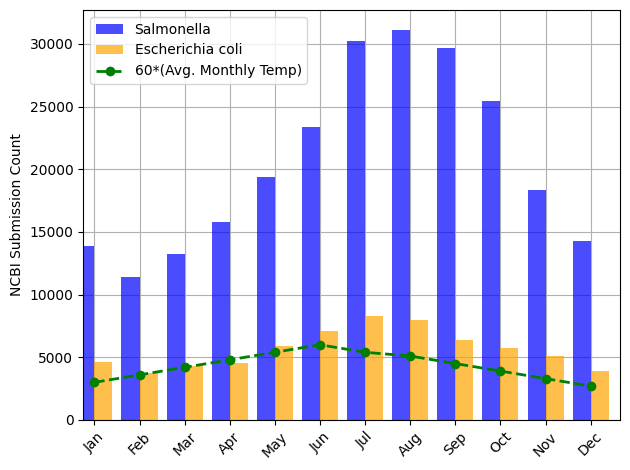

In [17]:
#Make a bar chart displaying monthly_counts1 and monthly_counts2, and overlaying the average monthly temperatures as a line plot
monthly_counts2.plot(kind='bar', color='blue', alpha=0.7, position=1, width=0.4, label='Salmonella')
monthly_counts1.plot(kind='bar', color='orange', alpha=0.7, position=0, width=0.4, label='Escherichia coli')
months_and_temps.plot(kind='line', color='green', marker='o', linestyle='--', linewidth=2, label='60*(Avg. Monthly Temp)')
plt.grid()
#place bars in front of grid

plt.xlabel('')
plt.ylabel('NCBI Submission Count')
plt.xticks(rotation=45)
plt.gca().set_axisbelow(True)
handles, labels = plt.gca().get_legend_handles_labels()
# Now you can safely reorder as needed
order = [1, 2, 0]  # E. coli (orange), Salmonella (blue), Temp (green)
plt.legend([handles[i] for i in order], [labels[i] for i in order])
plt.tight_layout()
plt.savefig('../outputs/submissions_by_month_562_590.tiff', dpi=300)
plt.show()
